In [1]:
# Projeto: Churn Prediction - Telco Customer Churn
# Objetivo: prever cancelamento de clientes usando Machine Learning

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv(r"D:\Python Files\projeto_etl_telecom\WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
# Converter TotalCharges para numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Ver valores nulos
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df = df.dropna()

In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df = df.drop('customerID', axis=1)

In [13]:
df.shape

(7032, 20)

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"D:\Python Files\projeto_etl_telecom\WA_Fn-UseC_-Telco-Customer-Churn.csv")

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df.dropna()

df = df.drop('customerID', axis=1)

df.shape

(7032, 20)

In [3]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

X = df.drop('Churn', axis=1)
y = df['Churn']

In [4]:
y.value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [5]:
X = pd.get_dummies(X, drop_first=True)

In [6]:
X.shape

(7032, 30)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
y_train.value_counts(normalize=True)

Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

D:\Users\andre\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
model = LogisticRegression(max_iter=2000)

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [13]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

NameError: name 'accuracy_score' is not defined

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.8038379530916845
Precision: 0.6475903614457831
Recall: 0.5748663101604278
F1: 0.6090651558073654
ROC-AUC: 0.8356727976766699


In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[916, 117],
       [159, 215]])

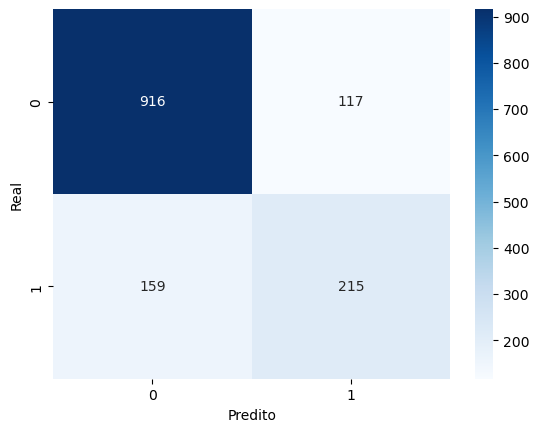

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

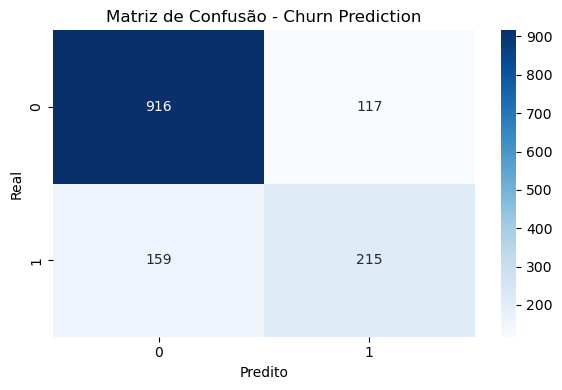

In [19]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Matriz de Confusão - Churn Prediction", fontsize=12)
plt.xlabel("Predito")
plt.ylabel("Real")

plt.tight_layout()
plt.show()

In [20]:
plt.savefig("confusion_matrix.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [2]:
from sklearn.linear_model import LogisticRegression

In [5]:
# ===== REATIVAÇÃO DO PROJETO =====

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# 1. Carregar dados
df = pd.read_csv(r"D:\Python Files\projeto_etl_telecom\WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2. Corrigir TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Remover nulos
df = df.dropna()

# 4. Remover ID
df = df.drop('customerID', axis=1)

# 5. Converter target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 6. Separar X e y
X = df.drop('Churn', axis=1)
y = df['Churn']

# 7. Encoding
X = pd.get_dummies(X, drop_first=True)

# 8. Dividir treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 9. Escalar dados
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 10. Treinar modelo
model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

# 11. Previsões
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Projeto reativado com sucesso!")

Projeto reativado com sucesso!


In [6]:
threshold = 0.3

y_pred_new = (y_proba >= threshold).astype(int)

print("Precision:", precision_score(y_test, y_pred_new))
print("Recall:", recall_score(y_test, y_pred_new))
print("F1:", f1_score(y_test, y_pred_new))

Precision: 0.5117117117117117
Recall: 0.7593582887700535
F1: 0.6114101184068891


In [7]:
cm_new = confusion_matrix(y_test, y_pred_new)

cm_new

array([[762, 271],
       [ 90, 284]])

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

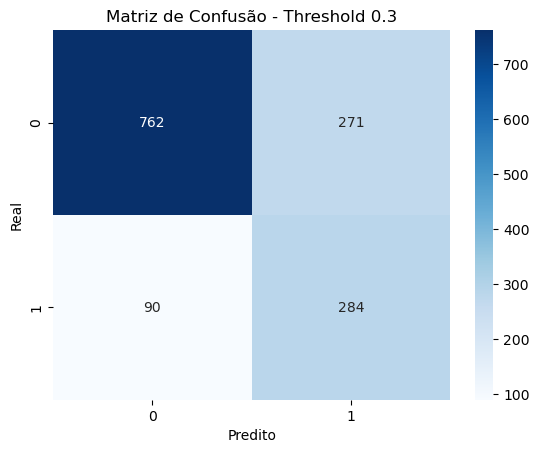

In [10]:
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão - Threshold 0.3")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

In [11]:
plt.savefig("confusion_matrix_threshold_03.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [12]:
import os

os.listdir()

['.anaconda',
 '.conda',
 '.continuum',
 '.copilot',
 '.gitconfig',
 '.ipynb_checkpoints',
 '.ipython',
 '.irpf',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '.receitanet',
 '.rfb',
 '.vscode',
 '01_churn_prediction_telco.ipynb',
 'Ambiente de Impressão',
 'Ambiente de Rede',
 'anaconda_projects',
 'Analise_Preditiva_Imoveis_BR.ipynb',
 'AppData',
 'colunas_modelo.pkl',
 'Configurações Locais',
 'confusion_matrix.png',
 'confusion_matrix_threshold_03.png',
 'Contacts',
 'Cookies',
 'Dados de Aplicativos',
 'Documents',
 'Downloads',
 'etl_telecom_gcp_powerbi.ipynb',
 'Favorites',
 'Links',
 'Menu Iniciar',
 'Meus Documentos',
 'Modelos',
 'modelo_aluguel_brasil.pkl',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{15d39e46-d952-11f0-8fe7-000b0e0f00ed}.TM.blf',
 'NTUSER.DAT{15d39e46-d952-11f0-8fe7-000b0e0f00ed}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{15d39e46-d952-11f0-8fe7-000b0e0f00ed}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'O

In [2]:
# ===== REATIVAÇÃO DO PROJETO CHURN =====

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# 1. Carregar dados
df = pd.read_csv(r"D:\Python Files\projeto_etl_telecom\WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2. Corrigir TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Remover nulos
df = df.dropna()

# 4. Remover ID
df = df.drop('customerID', axis=1)

# 5. Converter target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 6. Separar X e y
X = df.drop('Churn', axis=1)
y = df['Churn']

# 7. Encoding
X = pd.get_dummies(X, drop_first=True)

# 8. Dividir treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 9. Escalar dados
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 10. Treinar Logistic Regression
model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

# 11. Previsões
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Projeto reativado com sucesso!")

Projeto reativado com sucesso!


In [3]:
print(df.shape)
print(X_train.shape)
print(X_test.shape)

(7032, 20)
(5625, 30)
(1407, 30)


In [4]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

In [6]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))

Random Forest
Accuracy: 0.7889125799573561
Precision: 0.6323024054982818
Recall: 0.4919786096256685
F1: 0.5533834586466165
ROC-AUC: 0.8176693188936226


In [7]:
rf_cm = confusion_matrix(y_test, rf_pred)

rf_cm

array([[926, 107],
       [190, 184]])

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

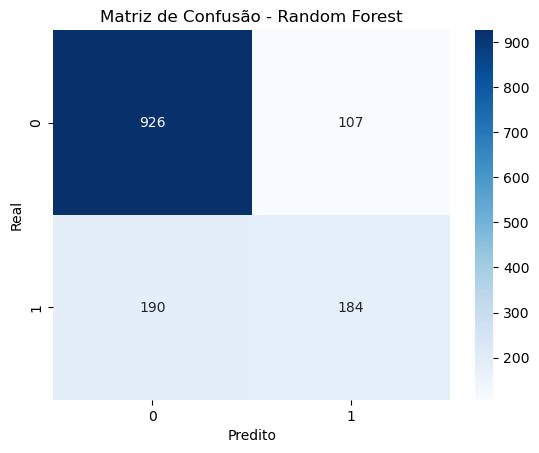

In [10]:
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

In [11]:
plt.savefig("confusion_matrix_random_forest.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

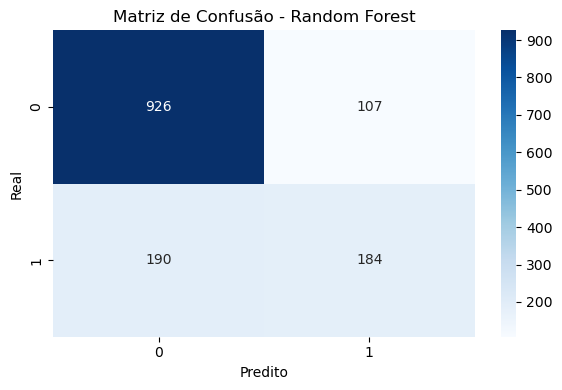

In [12]:
plt.figure(figsize=(6, 4))

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')

plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Predito")
plt.ylabel("Real")

plt.tight_layout()
plt.savefig("confusion_matrix_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
import os

[file for file in os.listdir() if file.endswith(".png")]

['confusion_matrix.png',
 'confusion_matrix_random_forest.png',
 'confusion_matrix_threshold_03.png']

In [14]:
import os

[file for file in os.listdir() if file.endswith(".png")]

['confusion_matrix.png',
 'confusion_matrix_random_forest.png',
 'confusion_matrix_threshold_03.png']

In [15]:
import shutil

project_folder = r"C:\Users\andre\churn-prediction-telco-ml"

files_to_update = [
    "01_churn_prediction_telco.ipynb",
    "confusion_matrix_random_forest.png"
]

for file in files_to_update:
    shutil.copy(file, project_folder)

print("Arquivos copiados para a pasta do GitHub!")

Arquivos copiados para a pasta do GitHub!


In [16]:
readme_text = """
# Churn Prediction - Telco Customer Churn

Projeto de Machine Learning para prever cancelamento de clientes (churn) utilizando dados da base Telco Customer Churn.

## Objetivo

Identificar clientes com maior probabilidade de cancelamento, permitindo que a empresa atue com estratégias de retenção.

## Etapas do projeto

- Limpeza e preparação dos dados
- Tratamento de valores ausentes
- Conversão de variáveis categóricas
- Separação entre treino e teste com estratificação
- Treinamento de modelo de Regressão Logística
- Ajuste de threshold para melhorar o recall
- Treinamento de modelo Random Forest
- Comparação entre modelos
- Análise da matriz de confusão

## Modelos utilizados

- Logistic Regression
- Random Forest

## Resultados dos modelos

### Logistic Regression - Threshold 0.5

- Accuracy: 0.83
- Precision: 0.65
- Recall: 0.57
- F1-score: 0.61
- ROC-AUC: 0.83

### Logistic Regression - Threshold 0.3

- Precision: 0.51
- Recall: 0.76
- F1-score: 0.61

### Random Forest

- Accuracy: 0.79
- Precision: 0.63
- Recall: 0.49
- F1-score: 0.55
- ROC-AUC: 0.82

## Comparação das matrizes de confusão

### Logistic Regression - Threshold 0.5

- Falsos negativos: 159
- Verdadeiros positivos: 215

### Logistic Regression - Threshold 0.3

- Falsos negativos: 90
- Verdadeiros positivos: 284

### Random Forest

- Falsos negativos: 190
- Verdadeiros positivos: 184

## Conclusão

Neste projeto, o principal objetivo era identificar clientes com maior risco de churn.

A Regressão Logística com threshold ajustado para 0.3 apresentou o melhor recall, identificando mais clientes com risco de cancelamento.

O Random Forest foi testado como comparação, mas neste primeiro experimento teve recall menor e deixou passar mais clientes que realmente cancelaram.

Por isso, considerando o objetivo de negócio, a melhor opção até o momento foi a Regressão Logística com threshold 0.3.

## Ferramentas utilizadas

- Python
- Pandas
- Scikit-learn
- Matplotlib
- Seaborn
- Jupyter Notebook
"""

with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme_text)

print("README.md atualizado com sucesso!")

README.md atualizado com sucesso!


In [17]:
import shutil

project_folder = r"C:\Users\andre\churn-prediction-telco-ml"

shutil.copy("README.md", project_folder)

print("README atualizado copiado para a pasta do GitHub!")

README atualizado copiado para a pasta do GitHub!


In [18]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(10)

,feature,importance
3,TotalCharges,0.174454
1,tenure,0.164773
2,MonthlyCharges,0.154132
25,Contract_Two year,0.059141
28,PaymentMethod_Electronic check,0.038563
10,InternetService_Fiber optic,0.037743
24,Contract_One year,0.030802
13,OnlineSecurity_Yes,0.030568
4,gender_Male,0.025842
19,TechSupport_Yes,0.023328


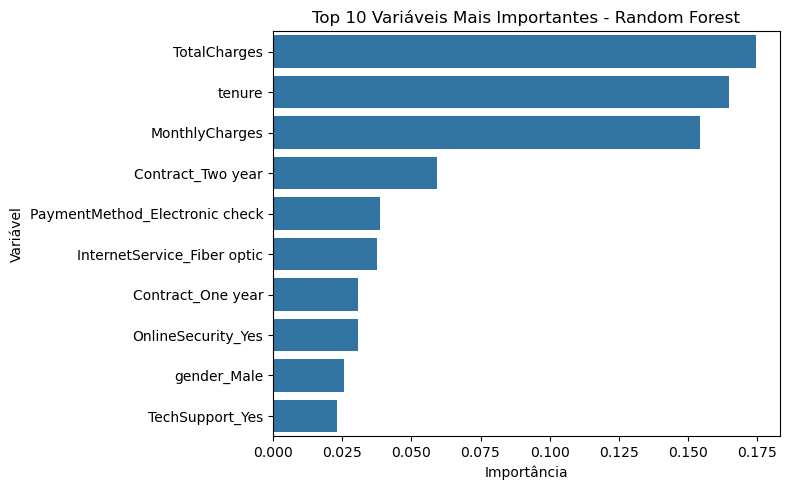

In [19]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top 10 Variáveis Mais Importantes - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

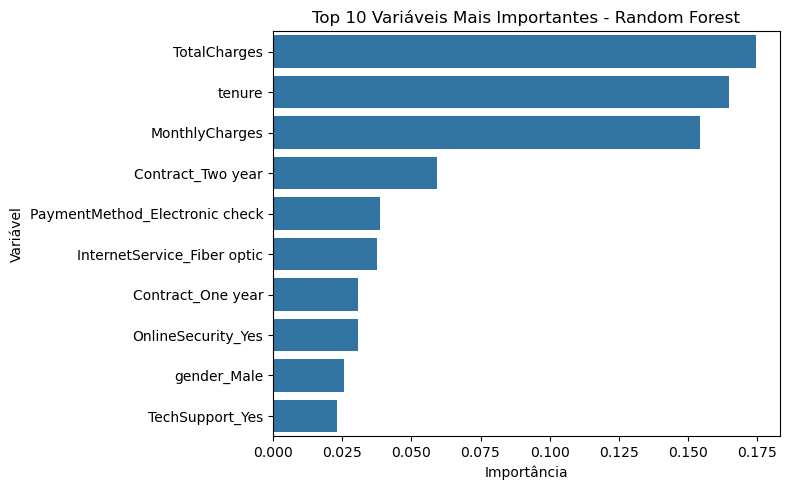

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top 10 Variáveis Mais Importantes - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.tight_layout()

plt.savefig("feature_importance_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
import os

[file for file in os.listdir() if file.endswith(".png")]

['confusion_matrix.png',
 'confusion_matrix_random_forest.png',
 'confusion_matrix_threshold_03.png',
 'feature_importance_random_forest.png']

In [22]:
import shutil

project_folder = r"C:\Users\andre\churn-prediction-telco-ml"

files_to_update = [
    "01_churn_prediction_telco.ipynb",
    "feature_importance_random_forest.png"
]

for file in files_to_update:
    shutil.copy(file, project_folder)

print("Arquivos copiados para a pasta do GitHub!")

Arquivos copiados para a pasta do GitHub!


In [2]:
## Conclusão provisória

Neste projeto foi desenvolvido um modelo de Machine Learning para prever churn de clientes.

Foram testados dois modelos principais:

- Logistic Regression
- Random Forest

A Regressão Logística com threshold ajustado para 0.3 apresentou melhor resultado para o objetivo de negócio, pois aumentou o recall e identificou mais clientes com risco de cancelamento.

O Random Forest foi utilizado como comparação e também permitiu analisar a importância das variáveis.

As variáveis mais relevantes foram relacionadas a:

- valor pago pelo cliente
- tempo de permanência
- tipo de contrato
- método de pagamento
- serviços contratados

Até o momento, o melhor modelo para o objetivo de retenção foi a Logistic Regression com threshold 0.3.

SyntaxError: invalid syntax (2012251870.py, line 3)

In [1]:
# ===== REATIVAÇÃO DO PROJETO CHURN =====

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# 1. Carregar dados
df = pd.read_csv(r"D:\Python Files\projeto_etl_telecom\WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2. Corrigir TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Remover nulos
df = df.dropna()

# 4. Remover ID
df = df.drop('customerID', axis=1)

# 5. Converter target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 6. Separar X e y
X = df.drop('Churn', axis=1)
y = df['Churn']

# 7. Encoding
X = pd.get_dummies(X, drop_first=True)

# 8. Dividir treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 9. Escalar dados para Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Projeto reativado com sucesso!")
print("df:", df.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Projeto reativado com sucesso!
df: (7032, 20)
X_train: (5625, 30)
X_test: (1407, 30)


In [2]:
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

rf_tuned.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,8
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [3]:
rf_tuned_pred = rf_tuned.predict(X_test)
rf_tuned_proba = rf_tuned.predict_proba(X_test)[:, 1]

In [4]:
print("Random Forest Ajustado")
print("Accuracy:", accuracy_score(y_test, rf_tuned_pred))
print("Precision:", precision_score(y_test, rf_tuned_pred))
print("Recall:", recall_score(y_test, rf_tuned_pred))
print("F1:", f1_score(y_test, rf_tuned_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_tuned_proba))

Random Forest Ajustado
Accuracy: 0.7469793887704336
Precision: 0.5157342657342657
Recall: 0.7887700534759359
F1: 0.6236786469344608
ROC-AUC: 0.8394363025505899


In [5]:
rf_tuned_cm = confusion_matrix(y_test, rf_tuned_pred)

rf_tuned_cm

array([[756, 277],
       [ 79, 295]])

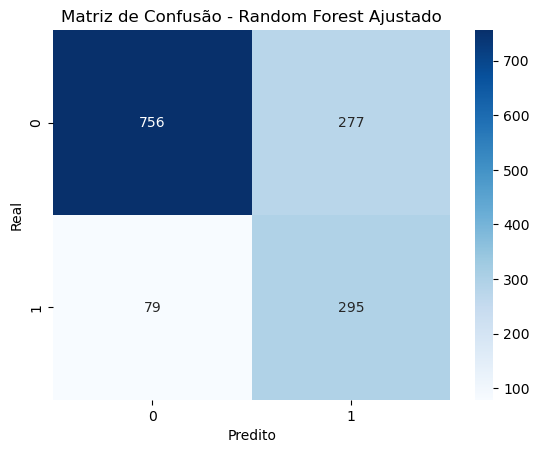

In [6]:
sns.heatmap(rf_tuned_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão - Random Forest Ajustado")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

In [7]:
plt.savefig("confusion_matrix_random_forest_tuned.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [8]:
import os

[file for file in os.listdir() if file.endswith(".png")]

['confusion_matrix.png',
 'confusion_matrix_random_forest.png',
 'confusion_matrix_random_forest_tuned.png',
 'confusion_matrix_threshold_03.png',
 'feature_importance_random_forest.png']